# Bitcoin_dataset

## Introduction :

Bitcoin (BTC) est un réseau consensuel qui permet un nouveau système de paiement et une monnaie entièrement numérique. Propulsé par ses utilisateurs, il se connecte à un réseau de paiement qui ne nécessite pas d'autorité centrale pour fonctionner. Le 31 octobre 2008, une personne ou un groupe de personnes travaillant sous le pseudonyme "Satoshi Nakamoto" a publié le livre blanc Bitcoin et l'a décrit comme suit : "Une version entièrement peer-to-peer de l'argent électronique, qui vous permet d'envoyer des paiements en ligne directement . De fête à une autre fête.

## Problème :

btc_market_price : Prix moyen en USD sur les principaux échanges de bitcoins.

btc_total_bitcoins : Le nombre total de bitcoins déjà extraits.

btc_market_cap : La valeur totale en USD de l'offre de bitcoins en circulation.

btc_trade_volume : La valeur totale en USD du volume des échanges sur les principaux échanges de bitcoins.

btc_blocks_size : La taille totale de tous les en-têtes de blocs et des transactions.

btc_avg_block_size : La taille moyenne des blocs en mégaoctets.

btc_n_orphaned_blocks : Le nombre total de blocs extraits mais finalement non attachés à la principale blockchain Bitcoin.

btc_n_transactions_per_block : Le nombre moyen de transactions par bloc.

btc_median_confirmation_time : Le temps médian pour qu'une transaction soit acceptée dans un bloc extrait.

btc_hash_rate : Le nombre estimé de térahashes par seconde que le réseau Bitcoin effectue.

btc_difficulty : Une mesure relative de la difficulté à trouver un nouveau bloc.

btc_miners_revenue : La valeur totale des récompenses de bloc Coinbase et des frais de transaction payés aux mineurs.

btc_transaction_fees : La valeur totale de tous les frais de transaction payés aux mineurs.

btc_cost_per_transaction_percent : Les revenus des mineurs en pourcentage du volume des transactions.

btc_cost_per_transaction : Les revenus des mineurs divisés par le nombre de transactions.

btc_n_unique_addresses : Le nombre total d'adresses uniques utilisées sur la blockchain Bitcoin.

btc_n_transactions : Le nombre de transactions Bitcoin confirmées quotidiennement.

btc_n_transactions_total : Le nombre total de transactions.

btc_n_transactions_excluding_popular : Le nombre total de transactions Bitcoin, en excluant les 100 adresses les plus populaires.

btc_n_transactions_excluding_chains_longer_than_100 : Le nombre total de transactions Bitcoin par jour, en excluant les chaînes de transactions longues.

btc_output_volume : La valeur totale de toutes les sorties de transaction par jour.

btc_estimated_transaction_volume : La valeur totale estimée des transactions sur la blockchain Bitcoin.

## Importer les packages :

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import  BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold, LeavePOut
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import  SVR
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix, r2_score
from sklearn.metrics import mean_squared_error


# I- Préparation du jeu de données :

## 1. Chargement du jeu de données :

In [34]:
data=pd.read_csv('bitcoin_dataset.csv')


In [35]:
data.head()

,Date,btc_market_price,btc_total_bitcoins,btc_market_cap,btc_trade_volume,btc_blocks_size,btc_avg_block_size,btc_n_orphaned_blocks,btc_n_transactions_per_block,btc_median_confirmation_time,...,btc_cost_per_transaction_percent,btc_cost_per_transaction,btc_n_unique_addresses,btc_n_transactions,btc_n_transactions_total,btc_n_transactions_excluding_popular,btc_n_transactions_excluding_chains_longer_than_100,btc_output_volume,btc_estimated_transaction_volume,btc_estimated_transaction_volume_usd
0,2/17/2010,0.0,2043200.0,0.0,0.0,0.0,0.000235,0,1.0,0.0,...,31.781022,0.0,241,244,41240,244,244,65173.13,36500.0,0.0
1,2/18/2010,0.0,2054650.0,0.0,0.0,0.0,0.000241,0,1.0,0.0,...,154.463801,0.0,234,235,41475,235,235,18911.74,7413.0,0.0
2,2/19/2010,0.0,2063600.0,0.0,0.0,0.0,0.000228,0,1.0,0.0,...,1278.516635,0.0,185,183,41658,183,183,9749.98,700.0,0.0
3,2/20/2010,0.0,2074700.0,0.0,0.0,0.0,0.000218,0,1.0,0.0,...,22186.687990,0.0,224,224,41882,224,224,11150.03,50.0,0.0
4,2/21/2010,0.0,2085400.0,0.0,0.0,0.0,0.000234,0,1.0,0.0,...,689.179876,0.0,218,218,42100,218,218,12266.83,1553.0,0.0


In [36]:
data.shape

(2906, 24)

## 2. Evaluation de la qualité des données et des valeurs manquantes :

In [37]:
# Obtenir un résumé statistique des données numériques de Data :
data.describe()

,btc_market_price,btc_total_bitcoins,btc_market_cap,btc_trade_volume,btc_blocks_size,btc_avg_block_size,btc_n_orphaned_blocks,btc_n_transactions_per_block,btc_median_confirmation_time,btc_hash_rate,...,btc_cost_per_transaction_percent,btc_cost_per_transaction,btc_n_unique_addresses,btc_n_transactions,btc_n_transactions_total,btc_n_transactions_excluding_popular,btc_n_transactions_excluding_chains_longer_than_100,btc_output_volume,btc_estimated_transaction_volume,btc_estimated_transaction_volume_usd
count,2906.000000,2.879000e+03,2.906000e+03,2.885000e+03,2877.000000,2906.000000,2906.000000,2906.000000,2894.000000,2.906000e+03,...,2906.000000,2906.000000,2.906000e+03,2906.000000,2.906000e+03,2906.000000,2906.000000,2.906000e+03,2.906000e+03,2.906000e+03
mean,839.104218,1.151138e+07,1.344352e+10,7.398381e+07,35505.502848,0.350366,0.364074,671.673651,7.501113,1.244070e+06,...,66.747821,14.639125,1.937861e+05,102081.138334,6.844558e+07,94348.852374,63140.320028,1.566216e+06,2.036475e+05,2.024338e+08
std,2304.972497,4.200024e+06,3.866841e+10,2.924228e+08,43618.633821,0.353168,0.842259,689.561322,4.974549,2.924141e+06,...,1761.894646,20.536083,2.089146e+05,103896.929350,8.285341e+07,103966.111763,69687.052174,2.278910e+06,2.682781e+05,5.800513e+08
min,0.000000,2.043200e+06,0.000000e+00,0.000000e+00,0.000000,0.000216,0.000000,1.000000,0.000000,2.250000e-05,...,0.136531,0.000000,1.100000e+02,118.000000,4.124000e+04,118.000000,118.000000,6.150000e+03,7.000000e+00,0.000000e+00
25%,6.653465,8.485300e+06,5.363081e+07,2.916456e+05,781.000000,0.024177,0.000000,54.000000,6.066667,1.160880e+01,...,1.181945,4.156470,1.675475e+04,8025.250000,2.413376e+06,6813.500000,6765.500000,4.901712e+05,9.600325e+04,9.581680e+05
50%,235.130000,1.243115e+07,3.346869e+09,1.001414e+07,15183.000000,0.196022,0.000000,375.000000,7.916667,2.176189e+04,...,2.493564,7.822430,1.304450e+05,62337.000000,3.255271e+07,53483.000000,35283.500000,1.105205e+06,1.784685e+05,3.742576e+07
75%,594.191164,1.520051e+07,8.075525e+09,2.834038e+07,58293.000000,0.676065,0.000000,1232.995223,10.208333,1.035363e+06,...,5.915591,14.800589,3.603765e+05,190471.250000,1.080663e+08,185901.750000,113793.250000,2.031654e+06,2.588046e+05,1.312499e+08
max,19498.683330,1.683769e+07,3.270000e+11,5.352016e+09,154444.590300,1.110327,7.000000,2722.625000,47.733333,2.160975e+07,...,88571.428570,161.686071,1.072861e+06,490644.000000,2.966888e+08,470650.000000,318896.000000,4.599222e+07,5.825066e+06,5.760245e+09


In [38]:
# Afficher des informations sur le Data : 
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2906 entries, 0 to 2905
Data columns (total 24 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Date                                                 2906 non-null   object 
 1   btc_market_price                                     2906 non-null   float64
 2   btc_total_bitcoins                                   2879 non-null   float64
 3   btc_market_cap                                       2906 non-null   float64
 4   btc_trade_volume                                     2885 non-null   float64
 5   btc_blocks_size                                      2877 non-null   float64
 6   btc_avg_block_size                                   2906 non-null   float64
 7   btc_n_orphaned_blocks                                2906 non-null   int64  
 8   btc_n_transactions_per_block                         2906 non-null  

In [39]:
# CONVERTIRE LA COLONE DATE:
data["Date"] = pd.to_datetime(data["Date"])
data["Annee"] = data["Date"].dt.year
data["Mois"] = data["Date"].dt.month
data["Jour"] = data["Date"].dt.day

data = data.drop('Date', axis=1)

In [40]:
data.head()

,btc_market_price,btc_total_bitcoins,btc_market_cap,btc_trade_volume,btc_blocks_size,btc_avg_block_size,btc_n_orphaned_blocks,btc_n_transactions_per_block,btc_median_confirmation_time,btc_hash_rate,...,btc_n_transactions,btc_n_transactions_total,btc_n_transactions_excluding_popular,btc_n_transactions_excluding_chains_longer_than_100,btc_output_volume,btc_estimated_transaction_volume,btc_estimated_transaction_volume_usd,Annee,Mois,Jour
0,0.0,2043200.0,0.0,0.0,0.0,0.000235,0,1.0,0.0,0.000029,...,244,41240,244,244,65173.13,36500.0,0.0,2010,2,17
1,0.0,2054650.0,0.0,0.0,0.0,0.000241,0,1.0,0.0,0.000029,...,235,41475,235,235,18911.74,7413.0,0.0,2010,2,18
2,0.0,2063600.0,0.0,0.0,0.0,0.000228,0,1.0,0.0,0.000023,...,183,41658,183,183,9749.98,700.0,0.0,2010,2,19
3,0.0,2074700.0,0.0,0.0,0.0,0.000218,0,1.0,0.0,0.000028,...,224,41882,224,224,11150.03,50.0,0.0,2010,2,20
4,0.0,2085400.0,0.0,0.0,0.0,0.000234,0,1.0,0.0,0.000027,...,218,42100,218,218,12266.83,1553.0,0.0,2010,2,21


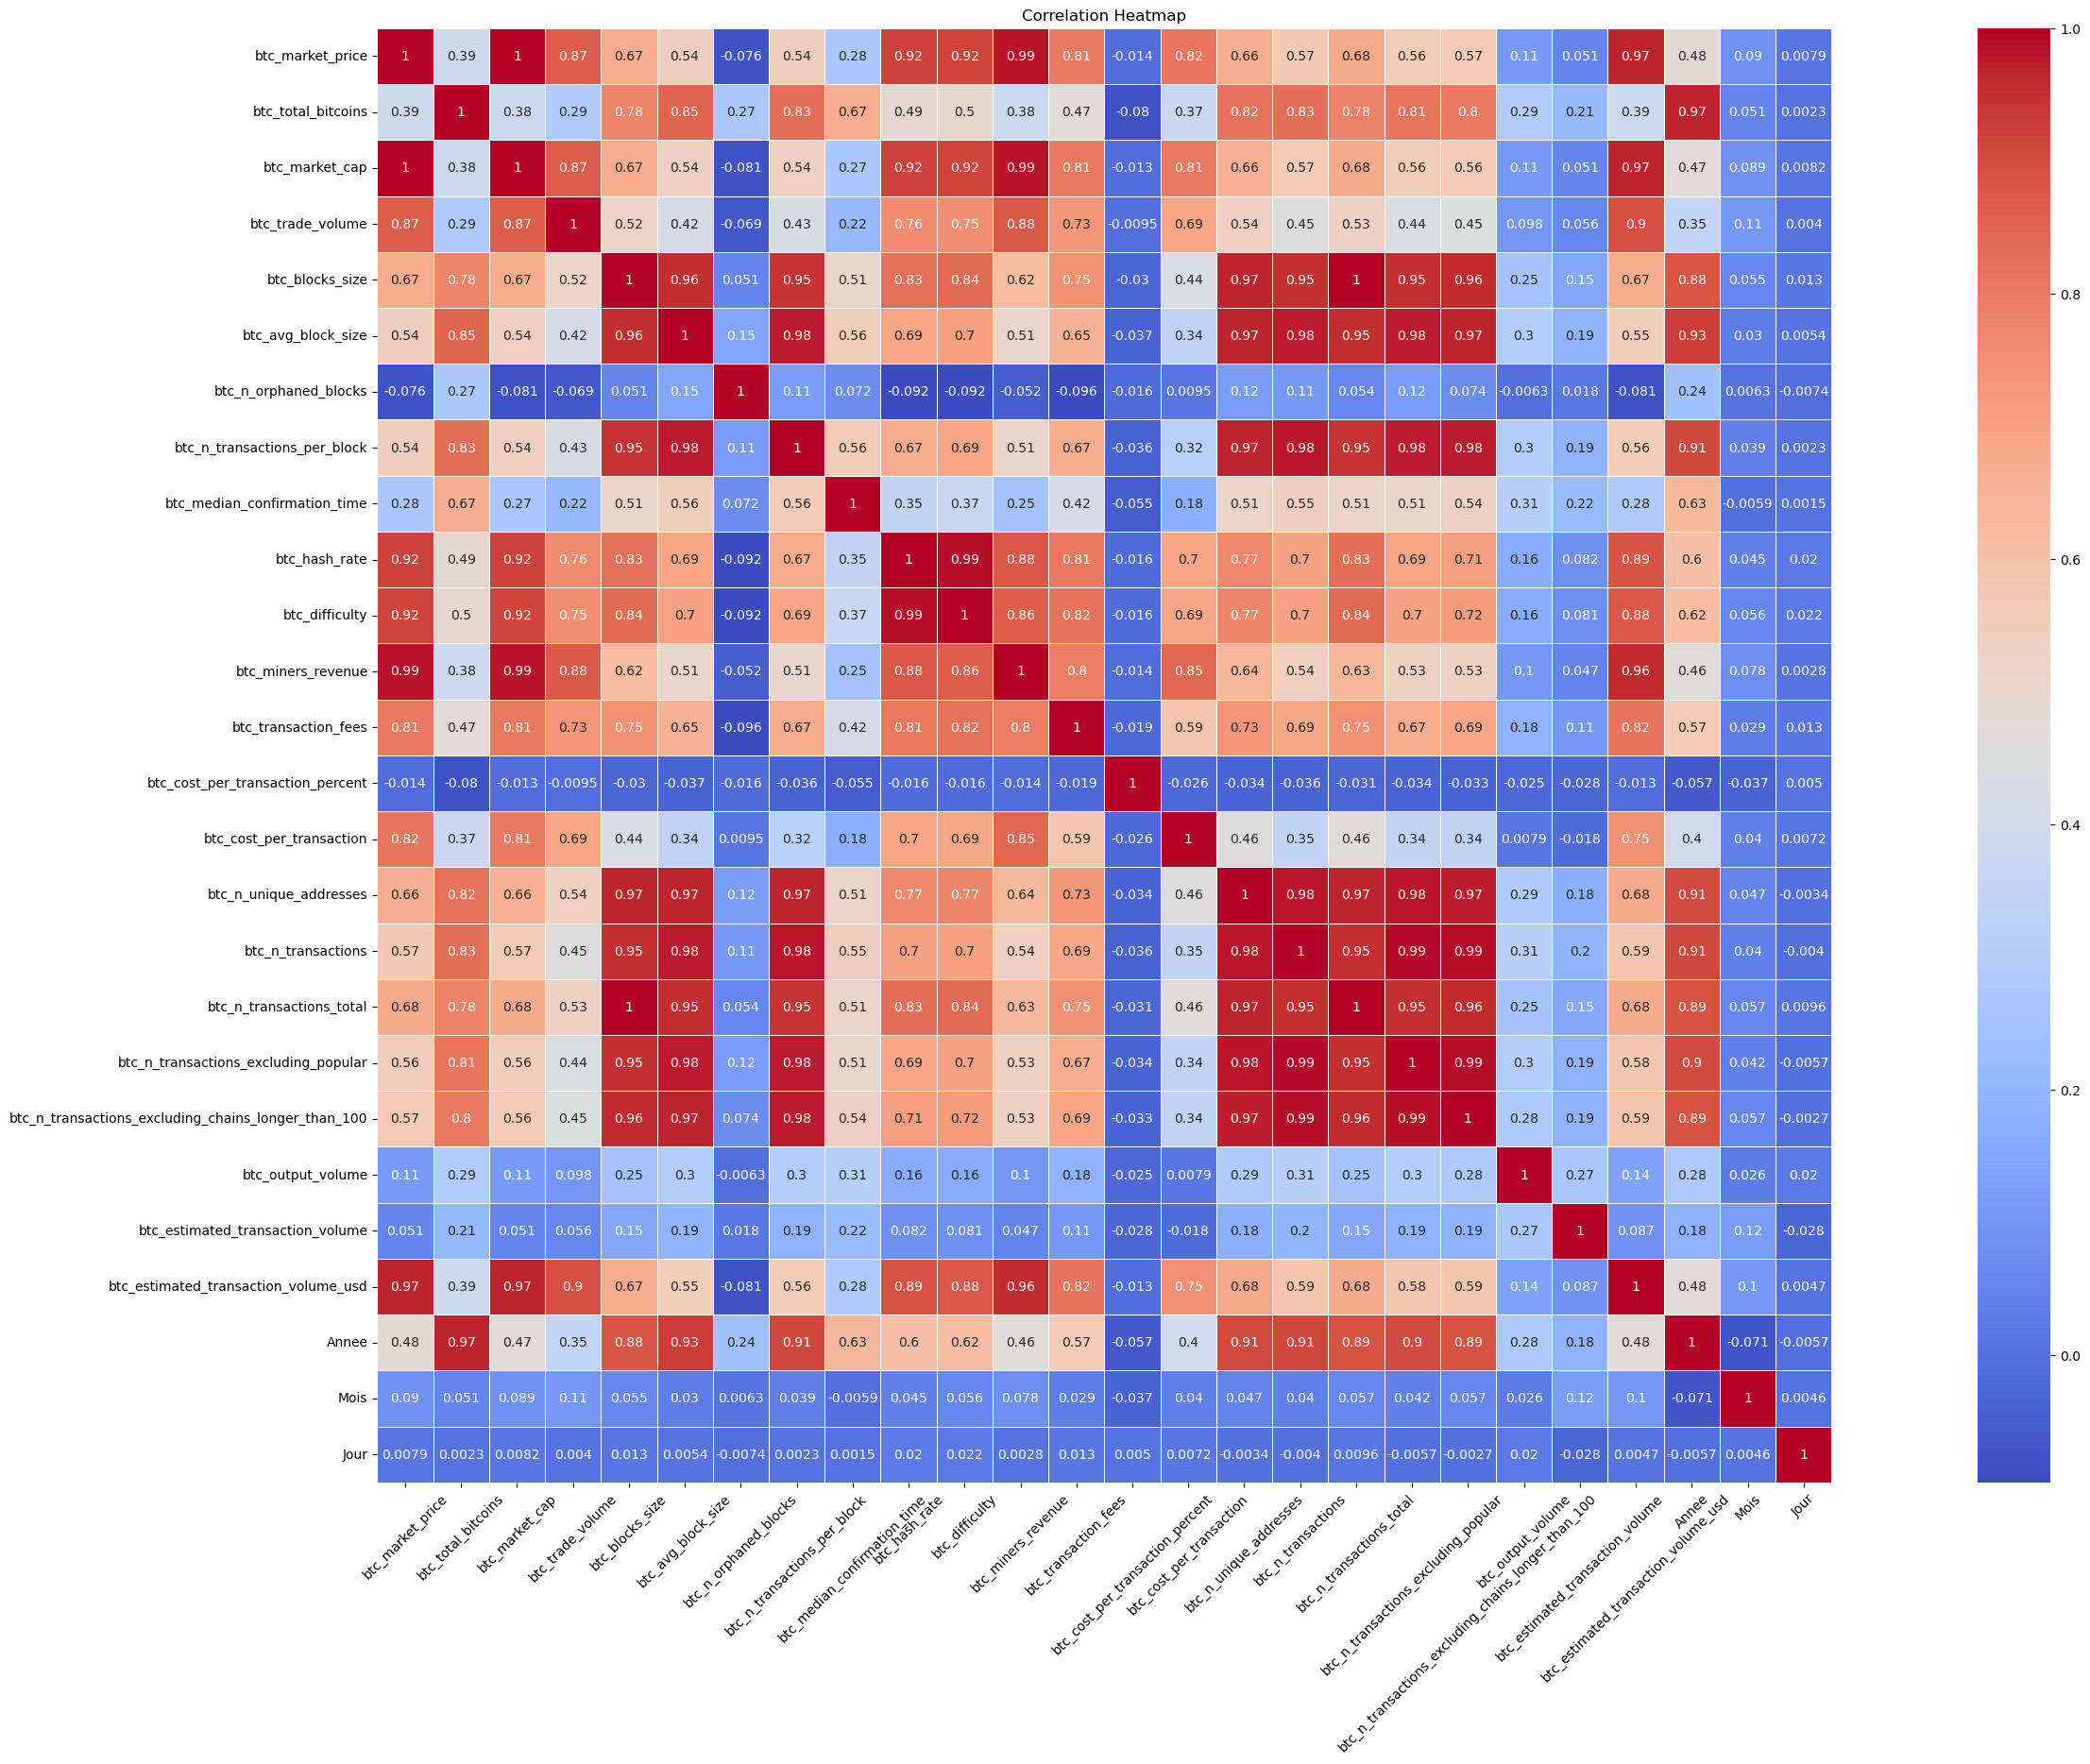

btc_total_bitcoins                                     0.392474
btc_market_cap                                         0.999783
btc_trade_volume                                       0.868813
btc_blocks_size                                        0.674507
btc_avg_block_size                                     0.544033
btc_n_orphaned_blocks                                 -0.076400
btc_n_transactions_per_block                           0.544125
btc_median_confirmation_time                           0.275250
btc_hash_rate                                          0.920876
btc_difficulty                                         0.916937
btc_miners_revenue                                     0.986732
btc_transaction_fees                                   0.806595
btc_cost_per_transaction_percent                      -0.013517
btc_cost_per_transaction                               0.815507
btc_n_unique_addresses                                 0.663917
btc_n_transactions                      

In [41]:
# Créer une heatmap (carte de chaleur) qui représente la matrice de corrélation des données :
# Créer une figure de grande taille
plt.figure(figsize=(40, 20))

# Calculer la matrice de corrélation et générer le heatmap
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, cbar=True, square=True, xticklabels=True, yticklabels=True)

# Ajuster les étiquettes des axes x et y pour une meilleure lisibilité
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)

# Ajouter un titre à la figure
plt.title('Correlation Heatmap', fontsize=12)

# Afficher la figure
plt.show()
target_correlations = correlation_matrix["btc_market_price"].drop("btc_market_price")
print(target_correlations)


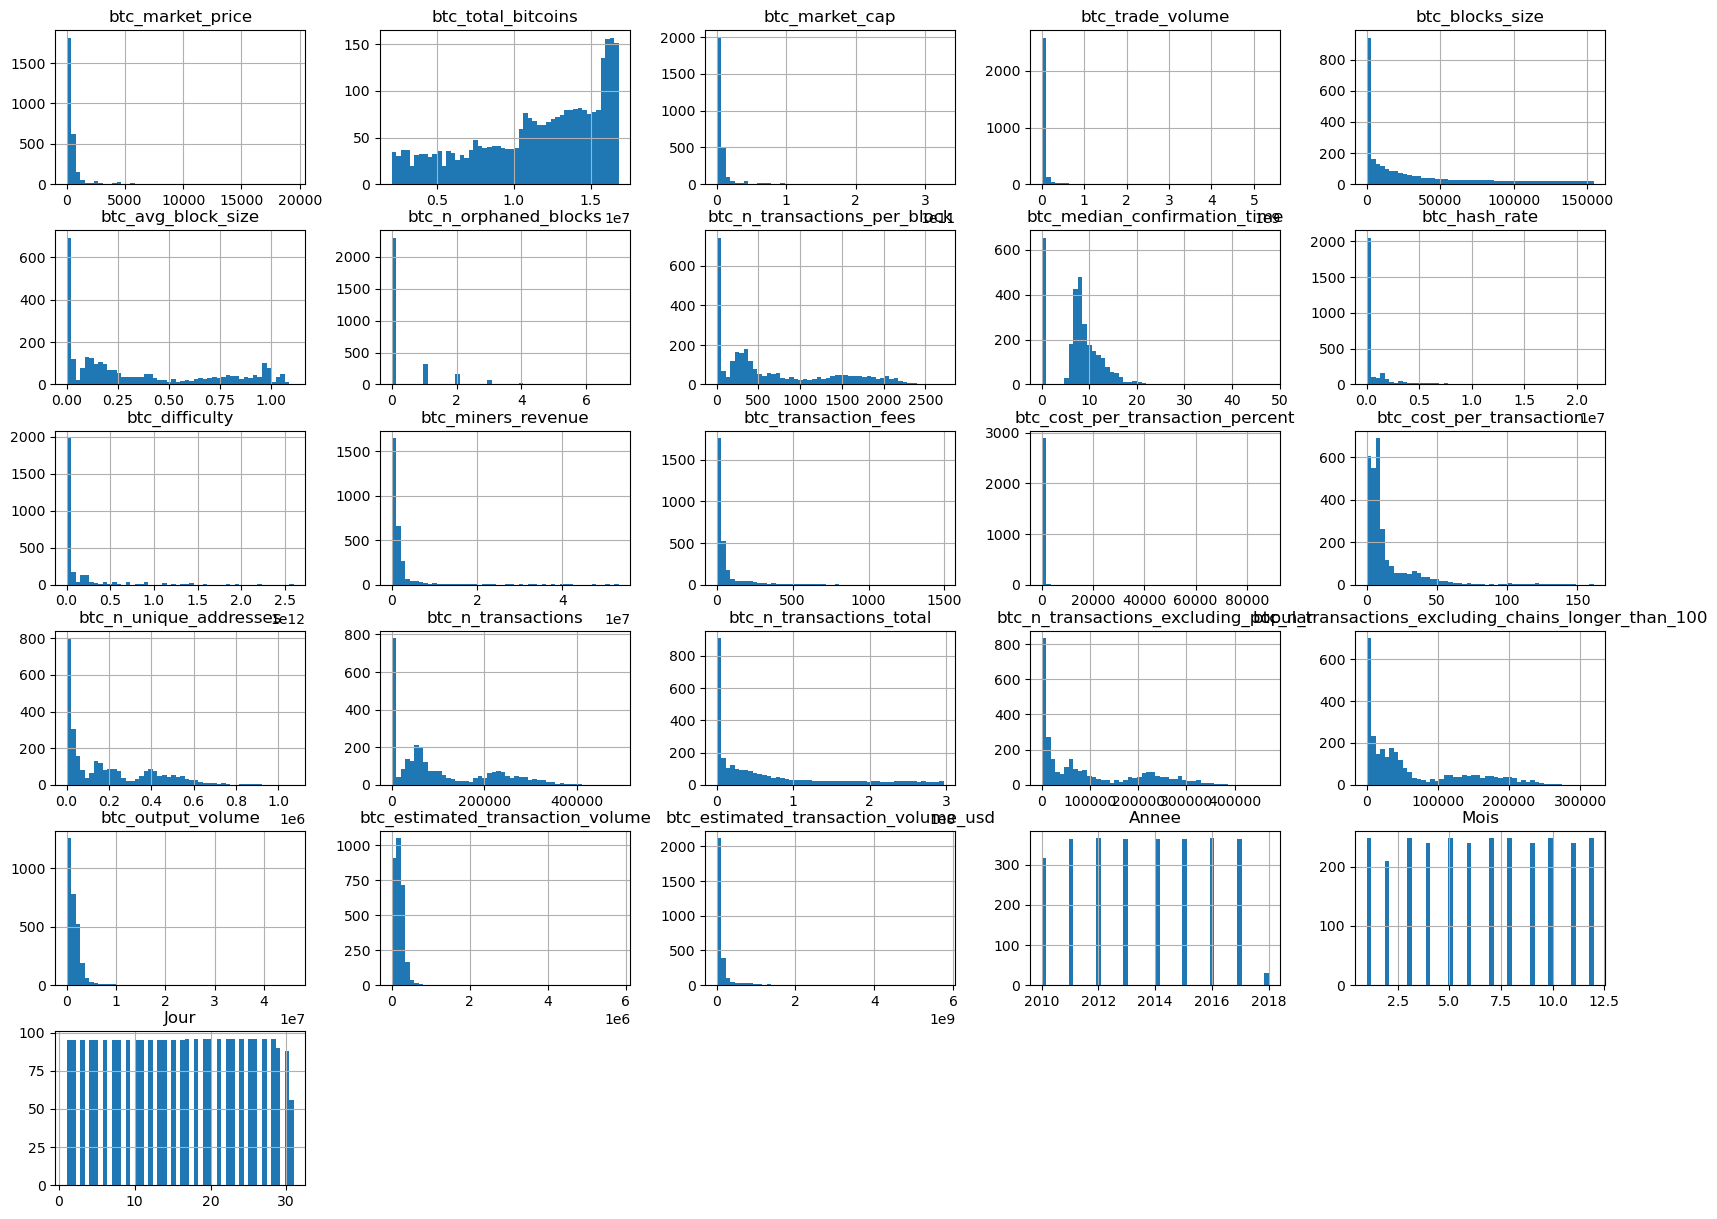

In [42]:
#Visualiser les distributions des variables
import matplotlib.pyplot as plt
data.hist(bins=50, figsize=(20,15))
plt.show()

In [43]:
# Calculer le nombre de valeurs manquantes dans chaque colonne du Data :
data.isnull().sum() 

btc_market_price                                        0
btc_total_bitcoins                                     27
btc_market_cap                                          0
btc_trade_volume                                       21
btc_blocks_size                                        29
btc_avg_block_size                                      0
btc_n_orphaned_blocks                                   0
btc_n_transactions_per_block                            0
btc_median_confirmation_time                           12
btc_hash_rate                                           0
btc_difficulty                                         16
btc_miners_revenue                                      0
btc_transaction_fees                                   10
btc_cost_per_transaction_percent                        0
btc_cost_per_transaction                                0
btc_n_unique_addresses                                  0
btc_n_transactions                                      0
btc_n_transact

In [44]:
# Trouver les lignes en double dans le Data :
duplicates = data.duplicated()
print(duplicates.sum())

0


## 3. Nettoyage des données :

In [45]:
#Détecter les valeurs aberrante :

# Calculer les statistiques descriptives (moyenne et écart-type)
mean = data.mean()
std = data.std()

# Définir les seuils supérieurs et inférieurs pour chaque attribut
threshold = 3  # Nombre d'écart-types pour définir les seuils
lower_threshold = mean - threshold * std
upper_threshold = mean + threshold * std

# Vérifier si chaque valeur est aberrante
outliers = (data < lower_threshold) | (data > upper_threshold)

# Afficher les valeurs aberrantes
aberrant_values = data[outliers]

# Afficher les lignes contenant des valeurs aberrantes
aberrant_rows = data[outliers.any(axis=1)]

# Supprimer les lignes contenant des valeurs aberrantes
cleaned_data = data[~outliers.any(axis=1)]

In [46]:
cleaned_data.shape

(2573, 26)

**Dans l'instruction suivante, nous voulons créer l'histogramme des variables en utilisant les arguments suivants :**
  * bins=50 : spécifie le nombre de bacs ou de catégories dans lesquels les valeurs seront regroupée
  * figsize=(20,15) : définit la taille de la figure dans laquelle l'histogramme sera tracé. Ces valeurs spécifiques (20, 15) déterminent les dimensions de la figure en pouces.

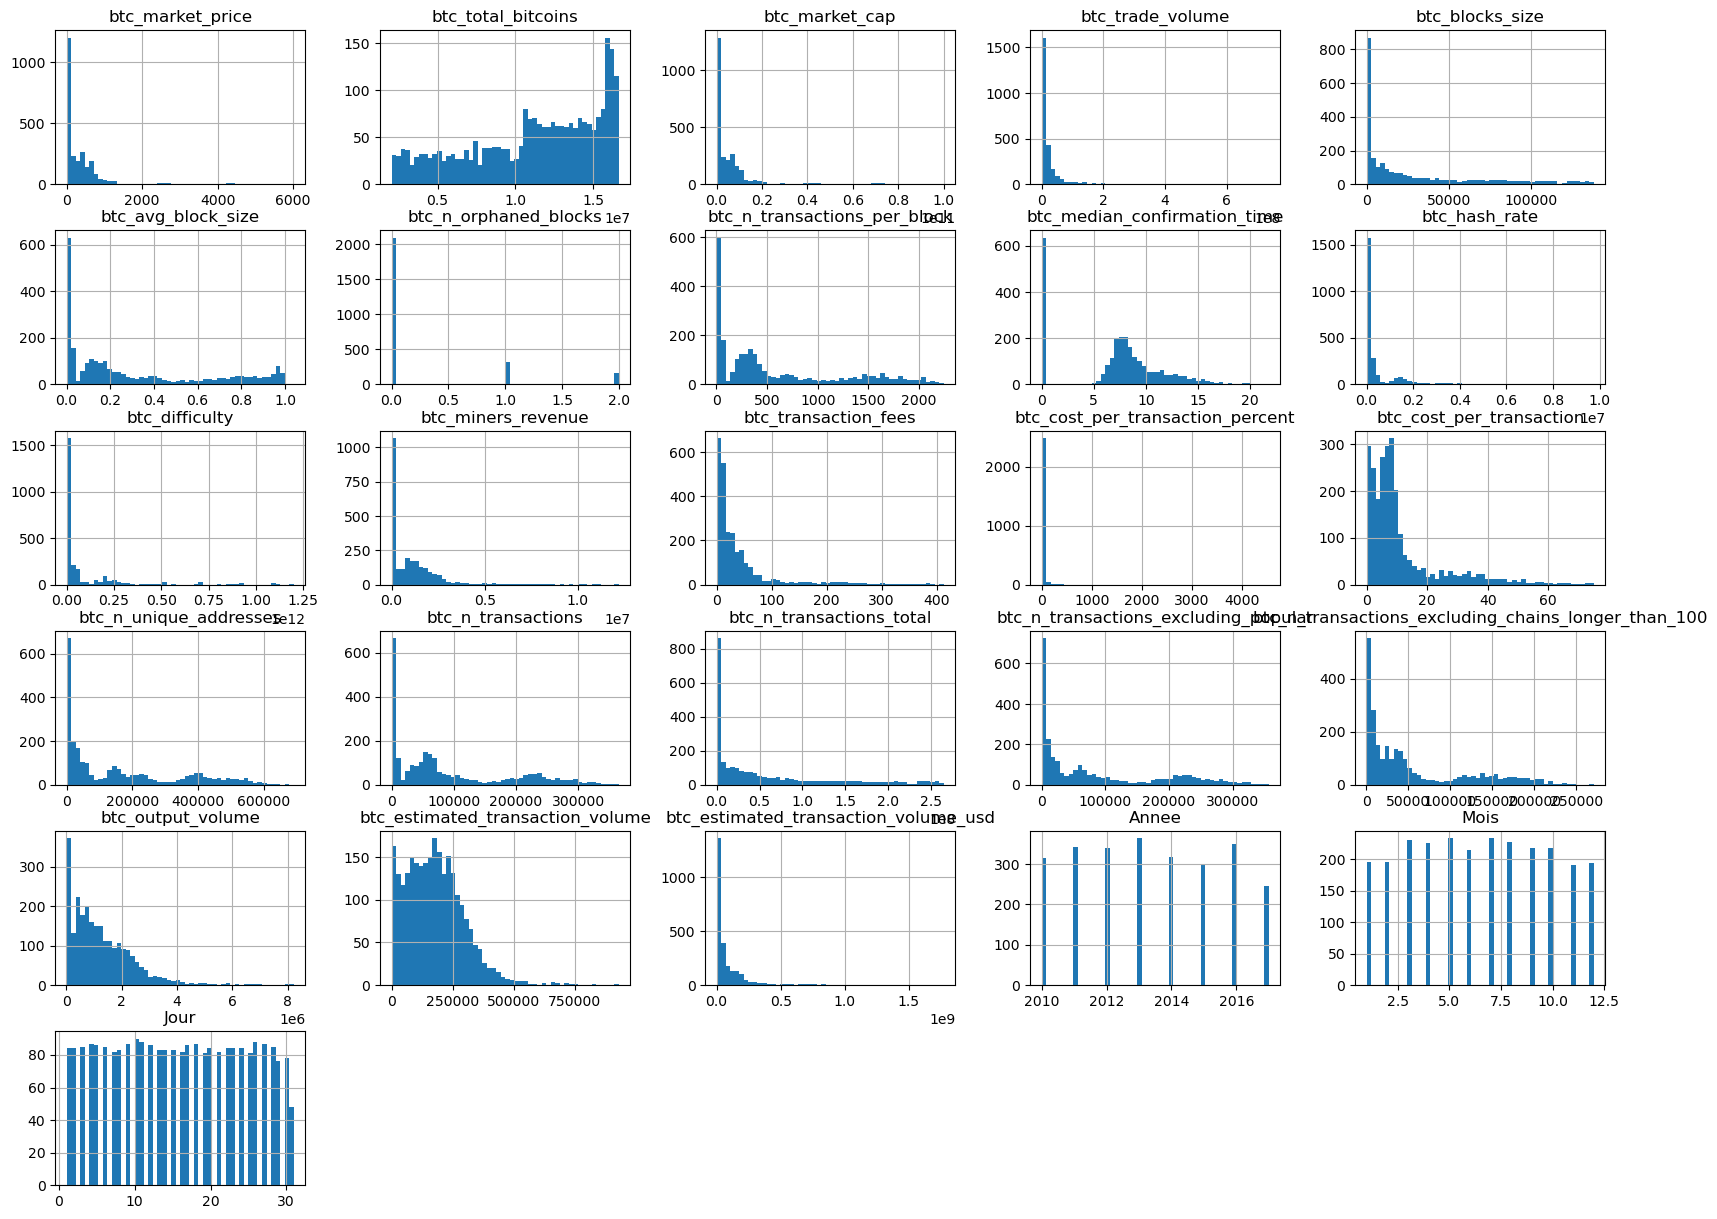

In [47]:
# Visualiser les distributions des variables
cleaned_data.hist(bins=50, figsize=(20,15))
plt.show()

In [48]:
# Suppression des valeurs manquantes :
new_data=cleaned_data.dropna()

In [49]:
new_data.isnull().sum()

btc_market_price                                       0
btc_total_bitcoins                                     0
btc_market_cap                                         0
btc_trade_volume                                       0
btc_blocks_size                                        0
btc_avg_block_size                                     0
btc_n_orphaned_blocks                                  0
btc_n_transactions_per_block                           0
btc_median_confirmation_time                           0
btc_hash_rate                                          0
btc_difficulty                                         0
btc_miners_revenue                                     0
btc_transaction_fees                                   0
btc_cost_per_transaction_percent                       0
btc_cost_per_transaction                               0
btc_n_unique_addresses                                 0
btc_n_transactions                                     0
btc_n_transactions_total       

In [50]:
new_data.shape

(2463, 26)

In [51]:
# # Selectioner les meilleurs features :
# import pandas as pd
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import cross_val_score

# # Chargement des données
#   # Assurez-vous de fournir le chemin correct vers votre fichier de données

# # Séparation des fonctionnalités et de la variable cible
# columns_to_extract = [col for col in new_data.columns if col != "btc_market_price"]
# X= new_data[columns_to_extract]

# y = new_data['btc_market_price']  # Variable cible

# # Création du modèle de régression linéaire
# regression_model = LinearRegression()

# # Calcul de l'importance des fonctionnalités avec validation croisée
# feature_importances = cross_val_score(regression_model, X, y, scoring='r2', cv=5)

# # Tri des fonctionnalités par ordre d'importance décroissante
# sorted_features = sorted(zip(X.columns, feature_importances), key=lambda x: x[1], reverse=True)

# # Affichage des meilleures fonctionnalités
# num_features =20# Nombre de meilleures fonctionnalités à afficher
# best_features = [feature for feature, _ in sorted_features[:num_features]]
# print('Meilleures fonctionnalités :', best_features)

### Autre methode de la selectionnement des meilleurs features à partir de la colleration des features :

In [52]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

# Chargement des données
  # Assurez-vous de fournir le chemin correct vers votre fichier de données

# Séparation des fonctionnalités et de la variable cible
X = new_data.drop('btc_market_price', axis=1)  # Fonctionnalités
y = new_data['btc_market_price']  # Variable cible

# Sélection des K meilleures fonctionnalités basées sur la corrélation
k = 8 # Nombre de meilleures fonctionnalités à sélectionner
selector = SelectKBest(score_func=f_regression, k=k)
X_new = selector.fit_transform(X, y)

# Obtention des indices des meilleures fonctionnalités sélectionnées
feature_indices = selector.get_support(indices=True)
best_features = X.columns[feature_indices]

# Affichage des meilleures fonctionnalités
print('Meilleures fonctionnalités :', best_features)

Meilleures fonctionnalités : Index(['btc_market_cap', 'btc_trade_volume', 'btc_blocks_size',
       'btc_hash_rate', 'btc_difficulty', 'btc_miners_revenue',
       'btc_n_transactions_total', 'btc_estimated_transaction_volume_usd'],
      dtype='object')


In [53]:
#new_data=new_data.drop(['btc_blocks_size','btc_trade_volume','btc_avg_block_size','btc_market_cap','btc_total_bitcoins'], axis = 1)


In [54]:
#new_data=new_data[['btc_market_cap','btc_trade_volume','btc_blocks_size','btc_hash_rate','btc_difficulty','btc_miners_revenue','btc_n_transactions_total','btc_estimated_transaction_volume_usd']]

### 5- Sélectionner les variables indépendantes (X) et la variable dépendante (Y):

In [55]:
columns_to_extract = [col for col in new_data.columns if col != "btc_market_price"]
X= new_data[columns_to_extract]
Y=new_data.iloc[:,0]
print(X)
print(Y)

      btc_total_bitcoins  btc_market_cap  btc_trade_volume  btc_blocks_size  \
0              2043200.0    0.000000e+00               0.0           0.0000   
1              2054650.0    0.000000e+00               0.0           0.0000   
2              2063600.0    0.000000e+00               0.0           0.0000   
4              2085400.0    0.000000e+00               0.0           0.0000   
5              2098150.0    0.000000e+00               0.0           0.0000   
...                  ...             ...               ...              ...   
2794          16619662.5    8.850187e+10       680358364.3      136395.6957   
2796          16623125.0    9.540741e+10       328701504.7      136679.4372   
2799          16629787.5    9.318856e+10       322503478.1      137175.2108   
2800          16631675.0    9.224220e+10       627801313.9      137328.8566   
2803          16638050.0    1.000000e+11       555571195.7      137842.6773   

      btc_avg_block_size  btc_n_orphaned_blocks  bt

### 6- Normaliser les données:

In [56]:
# Créer une instance de la classe PCA sans spécifier le nombre de composantes principales
# pca = PCA()

# # Effectuer l'analyse en composantes principales sur les données
# X_pca = pca.fit_transform(X)
# print(X_pca)
# X_pca.shape

In [57]:
scaler=StandardScaler()
X=scaler.fit_transform(X)
print(X)

[[-2.18881426 -0.50738071 -0.42041367 ... -1.54156934 -1.33416856
   0.15749006]
 [-2.18606051 -0.50738071 -0.42041367 ... -1.54156934 -1.33416856
   0.27141018]
 [-2.18390801 -0.50738071 -0.42041367 ... -1.54156934 -1.33416856
   0.3853303 ]
 ...
 [ 1.31929217  7.08394859  4.88814617 ...  1.64259228  1.03373428
   0.15749006]
 [ 1.31974612  7.00685642  9.91349299 ...  1.64259228  1.03373428
   0.27141018]
 [ 1.32127932  7.63882272  8.72455107 ...  1.64259228  1.03373428
   0.61317054]]


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Séparation des caractéristiques et de la variable cible
X =new_data.drop("btc_market_price", axis=1)
y = new_data["btc_market_price"]

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Création et entraînement du modèle KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
y_pred = knn.predict(X_test)

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
print("Erreur quadratique moyenne (RMSE) : ", mse**0.5)
r2 = r2_score(y_test, y_pred)
print("Coefficient de détermination (R²) : ", r2)

Erreur quadratique moyenne (RMSE) :  65.98934925835556
Coefficient de détermination (R²) :  0.9921664322432387


In [58]:
# X_train,X_test,Y_train,Y_test=train_test_split(X_pca,Y,test_size=0.30,random_state=1)
# print(X_train.shape)
# print(X_test.shape)
# print(Y_train.shape)
# print(Y_test.shape)

In [80]:
from sklearn.model_selection import cross_val_score

# Création du modèle KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=1)

# Validation croisée
scores = cross_val_score(knn,X_train , y_train, cv=3, scoring='r2')

# Affichage des scores
print("Scores de validation croisée (R²) : ", scores)
print("Score moyen de validation croisée (R²) : ", scores.mean())

Scores de validation croisée (R²) :  [0.99135497 0.99827075 0.99754013]
Score moyen de validation croisée (R²) :  0.9957219494105081


In [63]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(1970, 25)
(493, 25)
(1970,)
(493,)


## 8- Ajustement du modèle :

In [64]:

# Initialiser le modèle
model = LinearRegression()
# Diviser les données en ensembles d'entraînement et de test
#X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Entraîner le modèle sur l'ensemble d'entraînement
model.fit(X_train, Y_train)

# Faire des prédictions sur l'ensemble d'entraînement et de test
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculer l'erreur quadratique moyenne (RMSE) sur l'ensemble d'entraînement et de test
rmse_train = mean_squared_error(Y_train, y_train_pred, squared=False)
rmse_test = mean_squared_error(Y_test, y_test_pred, squared=False)

# Afficher les scores
print("RMSE sur l'ensemble d'entraînement:", rmse_train)
print("RMSE sur l'ensemble de test:", rmse_test)

# Comparer les scores pour détecter le surajustement
if rmse_train < rmse_test:
    print("Pas de surajustement (overfitting)")
else:
    print("Surajustement (overfitting) détecté")


RMSE sur l'ensemble d'entraînement: 10.774359214067497
RMSE sur l'ensemble de test: 11.22736135361022
Pas de surajustement (overfitting)


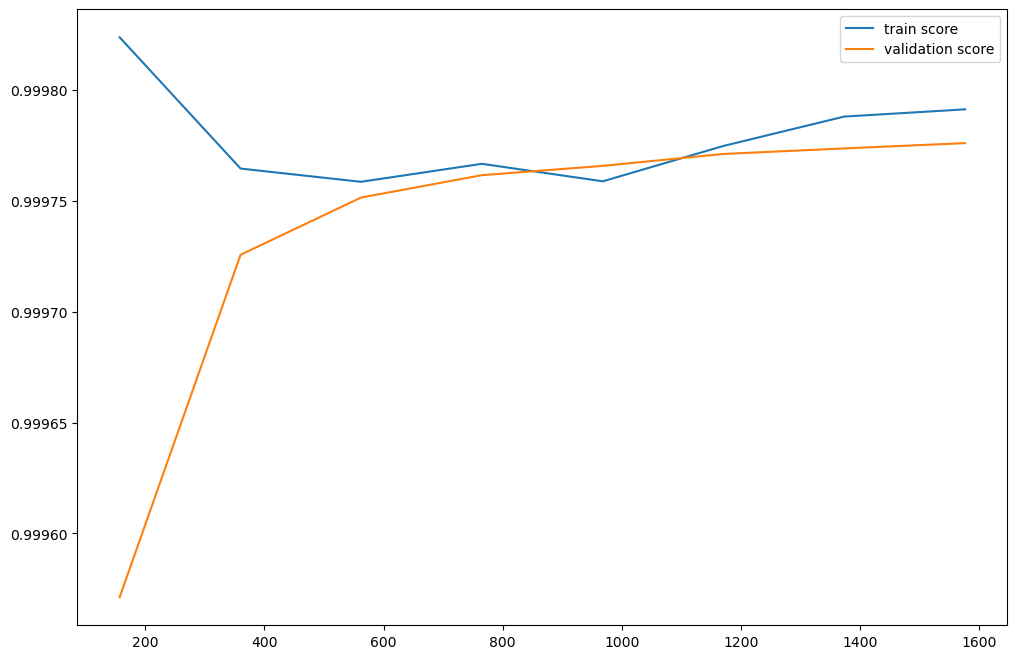

In [65]:
from sklearn.model_selection import learning_curve
N, train_score, val_score = learning_curve(model, X_train, Y_train,train_sizes=np.linspace(0.1, 1, 8))
plt.figure(figsize=(12, 8))
plt.plot(N, train_score.mean(axis=1), label='train score')
plt.plot(N, val_score.mean(axis=1), label='validation score')
plt.legend()
plt.show()

In [66]:
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.linear_model import Ridge
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error

# # Créer les caractéristiques polynomiales
# poly = PolynomialFeatures(degree=2)
# X_poly = poly.fit_transform(X)

# # Diviser les données en ensembles d'entraînement et de test
# #X_train, X_test, Y_train, Y_test = train_test_split(X_poly, Y, test_size=0.2, random_state=42)

# # Créer le modèle Ridge avec une régularisation de 0.5
# model = Ridge(alpha=0.5)

# # Entraîner le modèle sur les données d'entraînement
# model.fit(X_train, Y_train)

# # Faire des prédictions sur l'ensemble de test
# y_pred = model.predict(X_test)

# # Calculer l'erreur quadratique moyenne (RMSE) sur l'ensemble de test
# mse = mean_squared_error(Y_test, y_pred)
# rmse = np.sqrt(mse)
# print("RMSE:", rmse)
# r2 = r2_score(Y_test, y_pred)
# print("Coefficient de détermination (R²) : ", r2)


## II- Lineare regression

## 1.Ajustement du modèle de régression linéaire  et prédiction des résultats du test :

In [ ]:
model= LinearRegression()
model.fit(X,Y)

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
resultat=pd.DataFrame({'Actual':Y_test,'Predicted':y_pred})
print(resultat)

In [ ]:
# # Afficher les coefficients et l'intercept du modèle :
# print(model.coef_)  
# print(model.intercept_)

### 2- Evaluer le modèle : 

In [81]:
#calcul de R²
r2 = r2_score(Y_test, y_pred)
print("Coefficient de détermination (R²) : ", r2)

ValueError: Found input variables with inconsistent numbers of samples: [493, 739]

In [ ]:
from sklearn.model_selection import learning_curve
N, train_score, val_score = learning_curve(model, X_train, Y_train,train_sizes=np.linspace(0.1, 1, 8))
plt.figure(figsize=(12, 8))
plt.plot(N, train_score.mean(axis=1), label='train score')
plt.plot(N, val_score.mean(axis=1), label='validation score')
plt.legend()
plt.show()

### 3- Cross-validation :


In [ ]:
# Effectuer la validation croisée à 5 plis :  
scores=cross_val_score(model,X,Y,cv=5)
# Calculer la moyenne des scores de validation obtenus à partir de la validation croisée :
print('Moyenne des scores :',scores.mean())

## III- K_nearest neighbors (KNN) :

### 1- Ajuster le modèle :

In [ ]:
#  Effectuer la regression en utilisant les 10 voisins les plus proches :
knn=KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train,Y_train)
y_pred=knn.predict(X_test)

### 2- Evaluer le modèle:

In [ ]:
# Calculer la précision du modèle :
r2=r2_score(Y_test,y_pred)
print("Coefficient de détermination (R²) :", r2)

### 3- Choix de la meilleure valeur de k en utilisant Cross-Validation :

In [ ]:
scores=[]

for k in range(1,30):
    knn=KNeighborsRegressor(n_neighbors=k)
    score=cross_val_score(knn,X,Y,cv=5)
    scores.append(np.mean(score))
    
best_index = np.argmax(scores)
best_k = best_index + 1

print("Best K:", best_k, "Best Score:", scores[best_index])

In [ ]:
# plt.plot(range(1,30),scores,c='r')
# plt.xlabel("x")
# plt.ylabel("y")

## IV- Decision Tree :

In [ ]:
dtree=DecisionTreeRegressor()
dtree=dtree.fit(X,Y)

# Entrainer sur l'ensemble d'entrainement :
dtree.fit(X_train,Y_train)

# Faire des prédictions sue l'ensemble de test :
y_pred=dtree.predict(X_test)

# Evaluer le précision :
r2=r2_score(Y_test,y_pred)
print('Coefficient de détermination (R²) : ',r2)

## V- Méthode Ensembliste :

### 1- Bagging (Bootstrap Aggregating) :

In [ ]:
# Initialiser et entraîner le modèle Bagging:
model = BaggingRegressor(base_estimator=DecisionTreeRegressor(), random_state=42)
model.fit(X_train, Y_train)

# Faire des prédictions sur les données de test :
y_pred = model.predict(X_test)

# Calculer la précision du modèle :
r2 = r2_score(Y_test, y_pred)
print("Précision du modèle : ", r2)

### 2- Boosting :

#### a- Adaboost :

In [ ]:
# Initialiser et entraîner le modèle Adaboost :
model = AdaBoostRegressor()
model.fit(X_train, Y_train)

# Faire des prédictions sur les données de test :
y_pred = model.predict(X_test)

# Calculer la précision du modèle :
r2 = r2_score(Y_test, y_pred)
print("Précision du modèle : ", r2)

#### b- Gradient Boosting :

In [ ]:
# Initialiser et entraîner le modèle de Gradient Boosting :
model = GradientBoostingRegressor()
model.fit(X_train, Y_train)

# Faire des prédictions sur les données de test :
y_pred = model.predict(X_test)

# Calculer la précision du modèle :
r2 = r2_score(Y_test, y_pred)
print("Précision du modèle : ", r2)

### 3- Stacking :

In [ ]:
# Définir les modèles de base
base_models = [
    ('Linear', LinearRegression()),
    ('knn', KNeighborsRegressor())]#,('svm', SVC())]

# Initialiser le modèle Stacking 
model = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())

# Entraîner le modèle Stacking
model.fit(X_train, Y_train)

# Faire des prédictions sur les données de test
y_pred = model.predict(X_test)

# Calculer la précision du modèle
r2 = r2_score(Y_test, y_pred)
print("Précision du modèle : ", r2)

### 4- Random Forest :

In [ ]:
# Initialiser et entraîner le modèle Random Forest :
model = RandomForestRegressor()
model.fit(X_train, Y_train)

# Faire des prédictions sur les données de test
y_pred = model.predict(X_test)

# Calculer la précision du modèle
r2 = r2_score(Y_test, y_pred)
print("Précision du modèle : ", r2)

## VI- K-Means :

&#x25A0;**K-Means est un algorithme de clustering non supervisé utilisé pour regrouper un ensemble de données en différents groupes homogènes. Son objectif est de partitionner les données en k clusters, où chaque cluster est représenté par son centre appelé centroïde.** 

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)
y_means = kmeans.predict(X)
print(y_means)

## VII- Support Vector Machine (SVM) :

La machine à vecteurs de support (SVM) est un algorithme d'apprentissage supervisé. L'objectif principal de SVM est de trouver un hyperplan dans un espace de dimensions supérieures qui sépare de manière optimale les points de données de différentes classes

In [ ]:
model = SVR(kernel='poly', degree=3, C=1.0, epsilon=0.2)

model.fit(X_train,Y_train)
y_pred = model.predict(X_test)
r2=r2_score(Y_test,y_pred)
print(r2)

#### 